# Title: Project CNN (AlexNet)

# Objectives:
- To implement and train two different deep learning architectures (NN, AlexNet, and TinyVGG) on the CIFAR-10 dataset using PyTorch
- To compare their performance in terms of training time, accuracy, and generalization ability.


# Theory:

## Deep Learning for Image Classification

Deep learning is a subset of machine learning that uses artificial neural networks with multiple layers to learn hierarchical representations of data. In image classification tasks, deep neural networks automatically extract features such as edges, textures, shapes, and high-level object representations directly from raw pixel values.

Unlike traditional machine learning approaches that rely on handcrafted features, deep learning models learn feature representations directly.

In this lab, we compare three architectures of increasing complexity:

- Simple Neural Network (Fully Connected NN)
- TinyVGG (Compact CNN)
- AlexNet (Deep Convolutional Neural Network)

The goal is to analyze how architectural complexity affects training time, accuracy, convergence speed, and generalization ability.

## CIFAR-10 Dataset

The dataset used in this experiment is CIFAR-10, a widely used benchmark dataset for image classification tasks.

**Dataset Characteristics:**
- 60,000 color images
- Image size: 32 × 32 pixels
- 10 classes:
  - Airplane
  - Automobile
  - Bird
  - Cat
  - Deer
  - Dog
  - Frog
  - Horse
  - Ship
  - Truck
- Training set: 50,000 images
- Test set: 10,000 images

Normalization improves gradient stability and accelerates training by keeping input distributions centered.


## 1. Artificial Neural Network (NN)

A simple fully connected neural network consists of:

- Input layer
- One or more hidden layers
- Output layer

For CIFAR-10:
- Input dimension = 32 × 32 × 3 = 3072; no. of channels=3
- Output dimension = 10 (number of classes)

**Characteristics:**
- Uses linear layers 
- Activation function: ReLU
- Loss function

**Limitations:**
- Ignores spatial structure of images
- High number of parameters
- Prone to overfitting
- Poor performance compared to CNNs

This model serves as a baseline for comparison.

## 2. Convolutional Neural Networks (CNNs)

CNNs are specifically designed for image data. They use:

- **Convolutional layers** (feature extraction)
- **Pooling layers** (downsampling)
- **Fully connected layers** (classification)


## 3. AlexNet

AlexNet was introduced by Alex Krizhevsky, along with Ilya Sutskever and Geoffrey Hinton, in 2012. 

**Improvements of AlexNet Over Previous Methods:**
- **Deep CNN Architecture** – 8 learned layers.
- **ReLU Activation** – Faster training compared to tanh/sigmoid.
- **Dropout** – Reduced overfitting.
- **Data Augmentation** – Improved generalization.
- **GPU Training** – Enabled training of large networks.
- **Overlapping Max Pooling** – Reduced overfitting.

**Adaptation for CIFAR-10:**

Since CIFAR-10 images are 32×32 (much smaller than ImageNet's 224×224), modifications include:
- Smaller kernel size in first convolution layer
- Reduced stride
- Adjusted fully connected layers

AlexNet demonstrates how deeper architectures significantly outperform shallow networks in image classification.

## 4. TinyVGG

TinyVGG is a simplified version inspired by VGG-style architectures.

**Characteristics:**
- Small convolution blocks (Conv → ReLU → Conv → ReLU → MaxPool)
- Fewer filters than AlexNet
- Smaller number of parameters
- Faster training

**Purpose:**
- Demonstrate that simpler CNNs can perform competitively
- Reduce computational cost
- Improve efficiency while maintaining reasonable accuracy

TinyVGG balances performance and model complexity.

## 5. Optimizer

**Common optimizers:**
- SGD
- Adam

Adam is often preferred because:
- Adaptive learning rate
- Faster convergence
- Less sensitive to hyperparameters

The same optimizer is used for all models to ensure fair comparison.


In [83]:
# Import PyTorch
import torch
from torch import nn

# Import torchvision
import torchvision
from torchvision import datasets, transforms

# Import matplotlib for visualization
import matplotlib.pyplot as plt

# Check versions
# Note: your PyTorch version shouldn't be lower than 1.10.0 and torchvision version shouldn't be lower than 0.11
print(f"PyTorch version: {torch.__version__}\ntorchvision version: {torchvision.__version__}")

PyTorch version: 2.5.1+cu121
torchvision version: 0.20.1+cu121


In [84]:
mean = [0.4914, 0.4822, 0.4465]
std  = [0.2470, 0.2435, 0.2616]

train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=mean,
        std=std
    )
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],
        std=[0.2470, 0.2435, 0.2616]
    )
])

train_data = datasets.CIFAR10(
    root="data", # where to download data to?
    train=True, # get training data
    download=True, # download data if it doesn't exist on disk
    transform=train_transform, # images come as PIL format, we want to turn into Torch tensors
    target_transform=None # you can transform labels as well
)

# Setup testing data
test_data = datasets.CIFAR10(
    root="data",
    train=False, # get test data
    download=True,
    transform=train_transform
)

Files already downloaded and verified
Files already downloaded and verified


In [85]:
image, label = train_data[0]
image, label

(tensor([[[-1.0527e+00, -1.3068e+00, -1.1956e+00,  ...,  5.1906e-01,
            4.2380e-01,  3.6029e-01],
          [-1.7354e+00, -1.9895e+00, -1.7037e+00,  ..., -3.6628e-02,
           -1.0013e-01, -5.2505e-02],
          [-1.5926e+00, -1.7354e+00, -1.2115e+00,  ..., -1.1601e-01,
           -8.4258e-02, -2.5890e-01],
          ...,
          [ 1.3129e+00,  1.2018e+00,  1.1541e+00,  ...,  5.5081e-01,
           -1.1004e+00, -1.1480e+00],
          [ 8.6835e-01,  7.5721e-01,  9.6361e-01,  ...,  9.3186e-01,
           -4.4942e-01, -6.7170e-01],
          [ 8.2072e-01,  6.7783e-01,  8.5247e-01,  ...,  1.4399e+00,
            4.0792e-01, -3.6628e-02]],
 
         [[-9.8178e-01, -1.2395e+00, -1.2072e+00,  ...,  1.4557e-01,
            3.2838e-02,  1.6733e-02],
          [-1.6582e+00, -1.9803e+00, -1.8514e+00,  ..., -5.6305e-01,
           -6.4357e-01, -5.7915e-01],
          [-1.5938e+00, -1.8676e+00, -1.5455e+00,  ..., -6.2747e-01,
           -6.2747e-01, -8.0462e-01],
          ...,
    

In [86]:
image.shape

torch.Size([3, 32, 32])

In [87]:
class_names = train_data.classes
class_names

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

In [88]:
# How many samples are there?
len(train_data.data), len(train_data.targets), len(test_data.data), len(test_data.targets)

(50000, 50000, 10000, 10000)

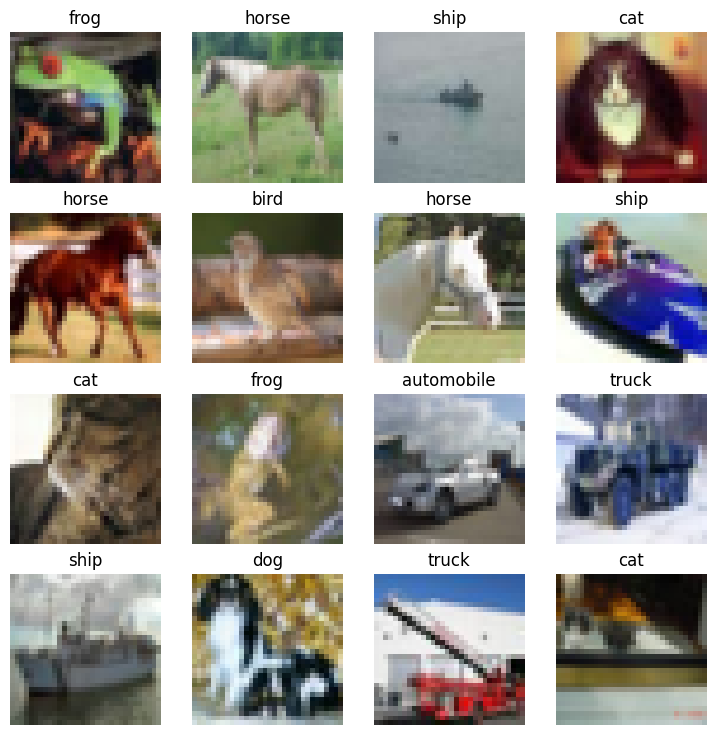

In [89]:
# plt.imshow(image.squeeze(), cmap="gray") # image shape is [1, 28, 28] (colour channels, height, width)
# plt.title(class_names[label]);


# Plot more images
torch.manual_seed(42)
fig = plt.figure(figsize=(9, 9))
rows, cols = 4, 4
for i in range(1, rows * cols + 1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    img, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3,1,1)
    std  = torch.tensor([0.2470, 0.2435, 0.2616]).view(3,1,1)
    img = img * std + mean   # unnormalize
    plt.imshow(img.permute(1, 2, 0))
    plt.title(class_names[label])
    plt.axis(False);

In [90]:
from torch.utils.data import DataLoader

# Setup the batch size hyperparameter
BATCH_SIZE = 32

# Turn datasets into iterables (batches)
train_dataloader = DataLoader(
    train_data, # dataset to turn into iterable
    batch_size=BATCH_SIZE, # how many samples per batch?
    shuffle=True # shuffle data every epoch?
)

test_dataloader = DataLoader(
    test_data,
    batch_size=BATCH_SIZE,
    shuffle=False # don't necessarily have to shuffle the testing data
)

# Let's check out what we've created
print(f"Dataloaders: {train_dataloader, test_dataloader}")
print(f"Length of train dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}")
print(f"Length of test dataloader: {len(test_dataloader)} batches of {BATCH_SIZE}")

Dataloaders: (<torch.utils.data.dataloader.DataLoader object at 0x000001C1DA6BCC90>, <torch.utils.data.dataloader.DataLoader object at 0x000001C1DA6924D0>)
Length of train dataloader: 1563 batches of 32
Length of test dataloader: 313 batches of 32


In [91]:
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 3, 32, 32]), torch.Size([32]))

In [92]:
# Create a flatten layer
flatten_model = nn.Flatten() # all nn modules function as a model (can do a forward pass)

# Get a single sample
x = train_features_batch[0]

# Flatten the sample
output = flatten_model(x) # perform forward pass

# Print out what happened
print(f"Shape before flattening: {x.shape} -> [color_channels, height, width]")
print(f"Shape after flattening: {output.shape} -> [color_channels, height*width]")

Shape before flattening: torch.Size([3, 32, 32]) -> [color_channels, height, width]
Shape after flattening: torch.Size([3, 1024]) -> [color_channels, height*width]


In [93]:
# Create a model with non-linear and linear layers
class ModelV1_NN(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(), # flatten inputs into single vector
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=output_shape),
            nn.ReLU()
        )

    def forward(self, x: torch.Tensor):
        return self.layer_stack(x)

In [94]:
# Setup device agnostic code
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [95]:
torch.manual_seed(42)
model_1 = ModelV1_NN(input_shape=3072, # number of input features
    hidden_units=10,
    output_shape=len(class_names) # number of output classes desired
).to(device) # send model to GPU if it's available
next(model_1.parameters()).device # check model device

device(type='cuda', index=0)

In [96]:
model = model_1
# Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss() # this is also called "criterion"/"cost function" in some places
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.001)

In [97]:
from timeit import default_timer as timer
def print_train_time(start: float, end: float, device: torch.device = None):
    """Prints difference between start and end time.

    Args:
        start (float): Start time of computation (preferred in timeit format).
        end (float): End time of computation.
        device ([type], optional): Device that compute is running on. Defaults to None.

    Returns:
        float: time between start and end in seconds (higher is longer).
    """
    total_time = end - start
    print(f"Train time on {device}: {total_time:.3f} seconds")
    return total_time

In [98]:
def accuracy_fn(y_true, y_pred):
    """Calculates accuracy between truth labels and predictions.

    Args:
        y_true (torch.Tensor): Truth labels for predictions.
        y_pred (torch.Tensor): Predictions to be compared to predictions.

    Returns:
        [torch.float]: Accuracy value between y_true and y_pred, e.g. 78.45
    """
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

In [99]:
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device = device):
    train_loss, train_acc = 0, 0
    model.to(device)
    for batch, (X, y) in enumerate(data_loader):
        # Send data to GPU
        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss
        train_acc += accuracy_fn(y_true=y,
                                 y_pred=y_pred.argmax(dim=1)) # Go from logits -> pred labels

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

    # Calculate loss and accuracy per epoch and print out what's happening
    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%")

def test_step(data_loader: torch.utils.data.DataLoader,
              model: torch.nn.Module,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device: torch.device = device):
    test_loss, test_acc = 0, 0
    model.to(device)
    model.eval() # put model in eval mode
    # Turn on inference context manager
    with torch.inference_mode():
        for X, y in data_loader:
            # Send data to GPU
            X, y = X.to(device), y.to(device)

            # 1. Forward pass
            test_pred = model(X)

            # 2. Calculate loss and accuracy
            test_loss += loss_fn(test_pred, y)
            test_acc += accuracy_fn(y_true=y,
                y_pred=test_pred.argmax(dim=1) # Go from logits -> pred labels
            )

        # Adjust metrics and print out
        test_loss /= len(data_loader)
        test_acc /= len(data_loader)
        print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%\n")

In [100]:
def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn,
               device: torch.device = device):
    """Evaluates a given model on a given dataset.

    Args:
        model (torch.nn.Module): A PyTorch model capable of making predictions on data_loader.
        data_loader (torch.utils.data.DataLoader): The target dataset to predict on.
        loss_fn (torch.nn.Module): The loss function of model.
        accuracy_fn: An accuracy function to compare the models predictions to the truth labels.
        device (str, optional): Target device to compute on. Defaults to device.

    Returns:
        (dict): Results of model making predictions on data_loader.
    """
    loss, acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:
            # Send data to the target device
            X, y = X.to(device), y.to(device)
            y_pred = model(X)
            loss += loss_fn(y_pred, y)
            acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))

        # Scale loss and acc
        loss /= len(data_loader)
        acc /= len(data_loader)
    return {"model_name": model.__class__.__name__, # only works when model was created with a class
            "model_loss": loss.item(),
            "model_acc": acc}

In [120]:
from tqdm import tqdm

# Measure time
from timeit import default_timer as timer

train_time_start_on_gpu = timer()
model = model
epochs = 10
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n---------")
    train_step(data_loader=train_dataloader,
        model=model,
        loss_fn=loss_fn,
        optimizer=optimizer,
        accuracy_fn=accuracy_fn
    )
    test_step(data_loader=test_dataloader,
        model=model,
        loss_fn=loss_fn,
        accuracy_fn=accuracy_fn
    )

train_time_end_on_gpu = timer()
total_train_time_model_1 = print_train_time(start=train_time_start_on_gpu,
                                            end=train_time_end_on_gpu,
                                            device=device)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 0
---------
Train loss: 0.88171 | Train accuracy: 69.13%


 10%|█         | 1/10 [00:13<02:02, 13.56s/it]

Test loss: 0.95319 | Test accuracy: 67.02%

Epoch: 1
---------
Train loss: 0.87203 | Train accuracy: 69.31%


 20%|██        | 2/10 [00:26<01:47, 13.39s/it]

...

Test loss: 0.94656 | Test accuracy: 67.91%

Epoch: 8
---------
Train loss: 0.82186 | Train accuracy: 71.32%


 90%|█████████ | 9/10 [01:58<00:13, 13.21s/it]

Test loss: 0.93953 | Test accuracy: 68.01%

Epoch: 9
---------
Train loss: 0.81700 | Train accuracy: 71.38%


100%|██████████| 10/10 [02:12<00:00, 13.22s/it]

Test loss: 0.93800 | Test accuracy: 68.37%

Train time on cuda: 132.213 seconds


In [121]:
# Calculate model 1 results with device-agnostic code
model_1_results = eval_model(
                        model=model_1,
                        data_loader=test_dataloader,
                        loss_fn=loss_fn,
                        accuracy_fn=accuracy_fn,
                        device=device
)
model_1_results

{'model_name': 'ModelV1',
 'model_loss': 1.6688082218170166,
 'model_acc': 40.16573482428115}

In [122]:
class ModelV2_TinyVGG(nn.Module):

    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.block_1 = nn.Sequential(
                            nn.Conv2d(in_channels=input_shape,
                                    out_channels=hidden_units,
                                    kernel_size=3, # how big is the square that's going over the image?
                                    stride=1, # default
                                    padding=1),# options = "valid" (no padding) or "same" (output has same shape as input) or int for specific number
                            nn.ReLU(),
                            nn.Conv2d(in_channels=hidden_units,
                                    out_channels=hidden_units,
                                    kernel_size=3,
                                    stride=1,
                                    padding=1),
                            nn.ReLU(),
                            nn.MaxPool2d(kernel_size=2,
                                        stride=2) # default stride value is same as kernel_size
        )
        self.block_2 = nn.Sequential(
                            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
                            nn.ReLU(),
                            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
                            nn.ReLU(),
                            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            # Where did this in_features shape come from?
            # It's because each layer of our network compresses and changes the shape of our input data.
            nn.Linear(in_features=hidden_units*8*8,
                      out_features=output_shape)
        )

    def forward(self, x: torch.Tensor):
        x = self.block_1(x)
        # print(x.shape)
        x = self.block_2(x)
        # print(x.shape)
        x = self.classifier(x)
        # print(x.shape)
        return x

In [123]:
model_2 = ModelV2_TinyVGG(
            input_shape=3,
            hidden_units=10,
            output_shape=len(class_names)
        ).to(device)
model_2

ModelV2_TinyVGG(
  (block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=640, out_features=10, bias=True)
  )
)

In [124]:
model = model_2
# Setup loss and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(),
                             lr=0.001)

In [125]:
torch.manual_seed(42)

# Measure time
from timeit import default_timer as timer
train_time_start_model_2 = timer()

# Train and test model
epochs = 10
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n---------")
    train_step(data_loader=train_dataloader,
        model=model_2,
        loss_fn=loss_fn,
        optimizer=optimizer,
        accuracy_fn=accuracy_fn,
        device=device
    )
    test_step(data_loader=test_dataloader,
        model=model_2,
        loss_fn=loss_fn,
        accuracy_fn=accuracy_fn,
        device=device
    )

train_time_end_model_2 = timer()
total_train_time_model_2 = print_train_time(start=train_time_start_model_2,
                                           end=train_time_end_model_2,
                                           device=device)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 0
---------
Train loss: 1.52302 | Train accuracy: 45.32%


 10%|█         | 1/10 [00:13<01:58, 13.12s/it]

Test loss: 1.28899 | Test accuracy: 53.92%

Epoch: 1
---------
Train loss: 1.23823 | Train accuracy: 56.16%


 20%|██        | 2/10 [00:26<01:44, 13.03s/it]

...

Test loss: 0.99950 | Test accuracy: 65.07%

Epoch: 8
---------
Train loss: 0.92008 | Train accuracy: 67.94%


 90%|█████████ | 9/10 [01:58<00:13, 13.30s/it]

Test loss: 0.98388 | Test accuracy: 65.97%

Epoch: 9
---------
Train loss: 0.90482 | Train accuracy: 68.58%


100%|██████████| 10/10 [02:11<00:00, 13.19s/it]

Test loss: 1.00121 | Test accuracy: 65.14%

Train time on cuda: 131.952 seconds


In [126]:
# Get model_2 results
model_2_results = eval_model(
    model=model_2,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn
)
model_2_results

{'model_name': 'ModelV2_TinyVGG',
 'model_loss': 1.0012145042419434,
 'model_acc': 65.13578274760384}

In [127]:
class AlexNetCIFAR(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(
            # Conv 1
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv 2
            nn.Conv2d(64, 192, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv 3
            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            # Conv 4
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            # Conv 5
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),

            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),

            nn.Linear(4096, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [128]:
model_3 = AlexNetCIFAR(
            num_classes=len(class_names)
        ).to(device)
model_3

AlexNetCIFAR(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=4096, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p

In [139]:
# Setup loss and optimizer specifically for model_3
loss_fn_3_ADAM = nn.CrossEntropyLoss()
optimizer_3_ADAM = torch.optim.Adam(params=model_3.parameters(), lr=0.001)

torch.manual_seed(42)

# Measure time
from timeit import default_timer as timer
train_time_start_model_3_ADAM = timer()

# Train and test model
epochs = 10
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n---------")
    train_step(data_loader=train_dataloader,
        model=model_3,
        loss_fn=loss_fn_3_ADAM,
        optimizer=optimizer_3_ADAM,
        accuracy_fn=accuracy_fn,
        device=device
    )
    test_step(data_loader=test_dataloader,
        model=model_3,
        loss_fn=loss_fn_3_ADAM,
        accuracy_fn=accuracy_fn,
        device=device
    )

train_time_end_model_3_ADAM = timer()
total_train_time_model_3_ADAM = print_train_time(start=train_time_start_model_3_ADAM,
                                           end=train_time_end_model_3_ADAM,
                                           device=device)


  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 0
---------
Train loss: 0.70428 | Train accuracy: 75.24%


 10%|█         | 1/10 [00:30<04:32, 30.33s/it]

Test loss: 0.88321 | Test accuracy: 69.89%

Epoch: 1
---------
Train loss: 0.61820 | Train accuracy: 77.92%


 20%|██        | 2/10 [01:00<04:01, 30.16s/it]

...

Test loss: 1.43376 | Test accuracy: 68.40%

Epoch: 8
---------
Train loss: 0.28103 | Train accuracy: 90.51%


 90%|█████████ | 9/10 [04:30<00:30, 30.11s/it]

Test loss: 1.57145 | Test accuracy: 69.19%

Epoch: 9
---------
Train loss: 0.27507 | Train accuracy: 90.80%


100%|██████████| 10/10 [05:01<00:00, 30.10s/it]

Test loss: 1.62757 | Test accuracy: 68.67%

Train time on cuda: 301.011 seconds


In [140]:
# Get model_3 results
model_3_results_ADAM = eval_model(
    model=model_3,
    data_loader=test_dataloader,
    loss_fn=loss_fn_3_ADAM,
    accuracy_fn=accuracy_fn
)
model_3_results_ADAM


{'model_name': 'AlexNetCIFAR',
 'model_loss': 1.6275715827941895,
 'model_acc': 68.67012779552715}

In [141]:
def make_predictions(model: torch.nn.Module, data: list, device: torch.device = device):
    pred_probs = []
    model.eval()
    with torch.inference_mode():
        for sample in data:
            # Prepare sample
            sample = torch.unsqueeze(sample, dim=0).to(device) # Add an extra dimension and send sample to device

            # Forward pass (model outputs raw logit)
            pred_logit = model(sample)

            # Get prediction probability (logit -> prediction probability)
            pred_prob = torch.softmax(pred_logit.squeeze(), dim=0) # note: perform softmax on the "logits" dimension, not "batch" dimension (in this case we have a batch size of 1, so can perform on dim=0)

            # Get pred_prob off GPU for further calculations
            pred_probs.append(pred_prob.cpu())

    # Stack the pred_probs to turn list into a tensor
    return torch.stack(pred_probs)

In [142]:
def plot_predictions(model: torch.nn.Module,
                     test_samples: list,
                     test_labels: list,
                     class_names: list,
                     title: str = None,
                     nrows: int = 3,
                     ncols: int = 3):
    """Makes predictions and plots results vs ground truth for a grid of test samples.

    Args:
        model (torch.nn.Module): Trained model to make predictions with.
        test_samples (list): List of image tensors to predict on.
        test_labels (list): Ground-truth label indices.
        class_names (list): List of class name strings.
        title (str, optional): Overall figure title. Defaults to None.
        nrows (int): Number of subplot rows. Defaults to 3.
        ncols (int): Number of subplot columns. Defaults to 3.

    Returns:
        torch.Tensor: Predicted class indices.
    """
    pred_probs = make_predictions(model=model, data=test_samples)
    pred_classes = pred_probs.argmax(dim=1)

    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    std  = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)

    plt.figure(figsize=(9, 9))
    if title:
        plt.suptitle(title, fontsize=14, fontweight="bold")

    for i, sample in enumerate(test_samples):
        plt.subplot(nrows, ncols, i + 1)
        img = sample * std + mean          # unnormalize
        plt.imshow(img.permute(1, 2, 0))

        pred_label  = class_names[pred_classes[i]]
        truth_label = class_names[test_labels[i]]
        title_text  = f"Pred: {pred_label} | Truth: {truth_label}"
        color = "g" if pred_label == truth_label else "r"
        plt.title(title_text, fontsize=10, c=color)
        plt.axis(False)

    plt.tight_layout()
    plt.show()
    return pred_classes


In [143]:
from tqdm.auto import tqdm
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

def plot_confusion_matrix_for_model(model: torch.nn.Module,
                                    dataloader: torch.utils.data.DataLoader,
                                    class_names: list,
                                    device: torch.device = device,
                                    title: str = None,
                                    figsize: tuple = (10, 7)):
    """Generates predictions over a full dataloader and plots the confusion matrix.

    Args:
        model (torch.nn.Module): Trained model to evaluate.
        dataloader (torch.utils.data.DataLoader): DataLoader to run inference on.
        class_names (list): List of class name strings for axis labels.
        device (torch.device): Device to run inference on. Defaults to device.
        title (str, optional): Title for the confusion matrix plot. Defaults to None.
        figsize (tuple): Figure size for the plot. Defaults to (10, 7).

    Returns:
        torch.Tensor: The (num_classes x num_classes) confusion matrix tensor.
    """
    y_preds = []
    model.eval()
    with torch.inference_mode():
        for X, y in tqdm(dataloader, desc=f"Making predictions{' for ' + title if title else ''}"):
            X, y = X.to(device), y.to(device)
            y_logit = model(X)
            y_pred = torch.softmax(y_logit, dim=1).argmax(dim=1)
            y_preds.append(y_pred.cpu())

    y_pred_tensor = torch.cat(y_preds)

    confmat = ConfusionMatrix(num_classes=len(class_names), task="multiclass")
    confmat_tensor = confmat(preds=y_pred_tensor,
                             target=torch.tensor(dataloader.dataset.targets))

    fig, ax = plot_confusion_matrix(
        conf_mat=confmat_tensor.numpy(),
        class_names=class_names,
        figsize=figsize
    )
    if title:
        ax.set_title(title, fontsize=14, fontweight="bold")
    plt.show()

    return confmat_tensor


In [144]:
import random
random.seed(67)
test_samples = []
test_labels = []
for sample, label in random.sample(list(test_data), k=9):
    test_samples.append(sample)
    test_labels.append(label)

# View the first test sample shape and label
print(f"Test sample image shape: {test_samples[0].shape}\nTest sample label: {test_labels[0]} ({class_names[test_labels[0]]})")

Test sample image shape: torch.Size([3, 32, 32])
Test sample label: 6 (frog)


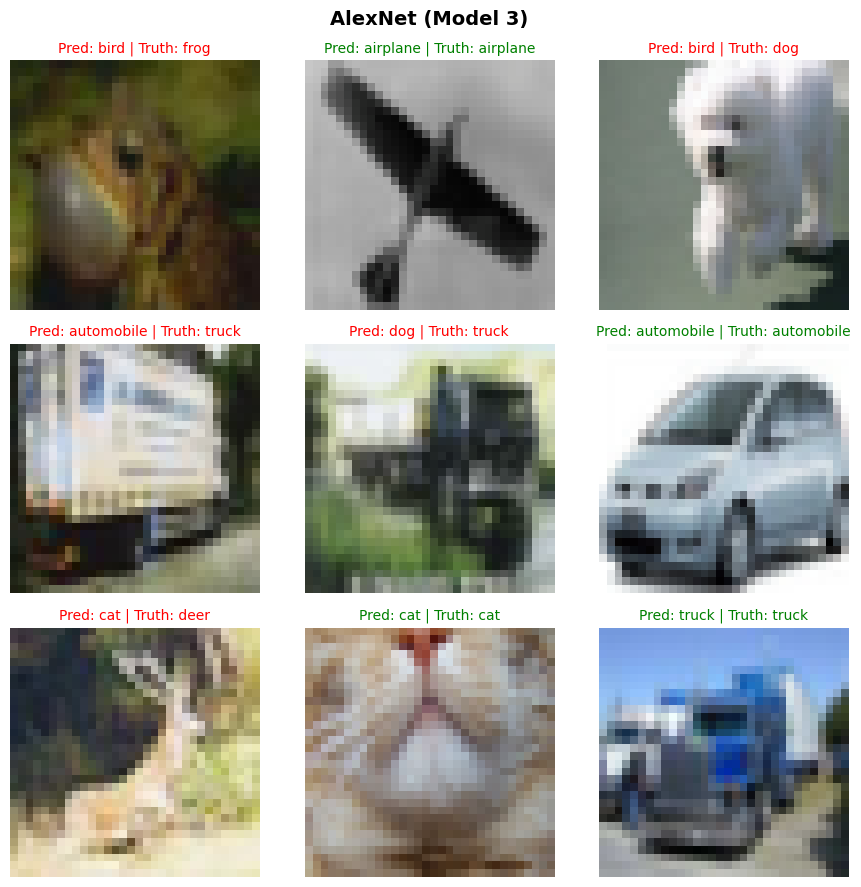

Predicted: [2, 0, 2, 1, 5, 1, 3, 3, 9]
Truth:     [6, 0, 5, 9, 9, 1, 4, 3, 9]


In [145]:
# AlexNet (Model 3) predictions
pred_classes_3 = plot_predictions(
    model=model_3,
    test_samples=test_samples,
    test_labels=test_labels,
    class_names=class_names,
    title="AlexNet (Model 3)"
)
print("Predicted:", pred_classes_3.tolist())
print("Truth:    ", test_labels)


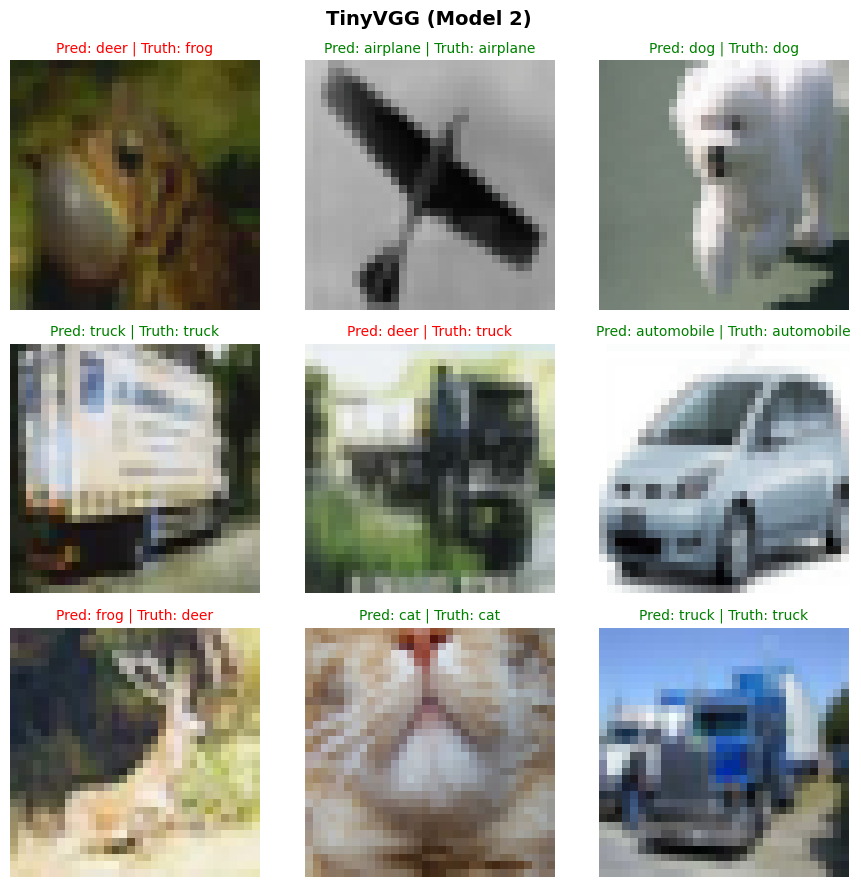

Predicted: [4, 0, 5, 9, 4, 1, 6, 3, 9]
Truth:     [6, 0, 5, 9, 9, 1, 4, 3, 9]


In [146]:
# TinyVGG (Model 2) predictions
pred_classes_2 = plot_predictions(
    model=model_2,
    test_samples=test_samples,
    test_labels=test_labels,
    class_names=class_names,
    title="TinyVGG (Model 2)"
)
print("Predicted:", pred_classes_2.tolist())
print("Truth:    ", test_labels)


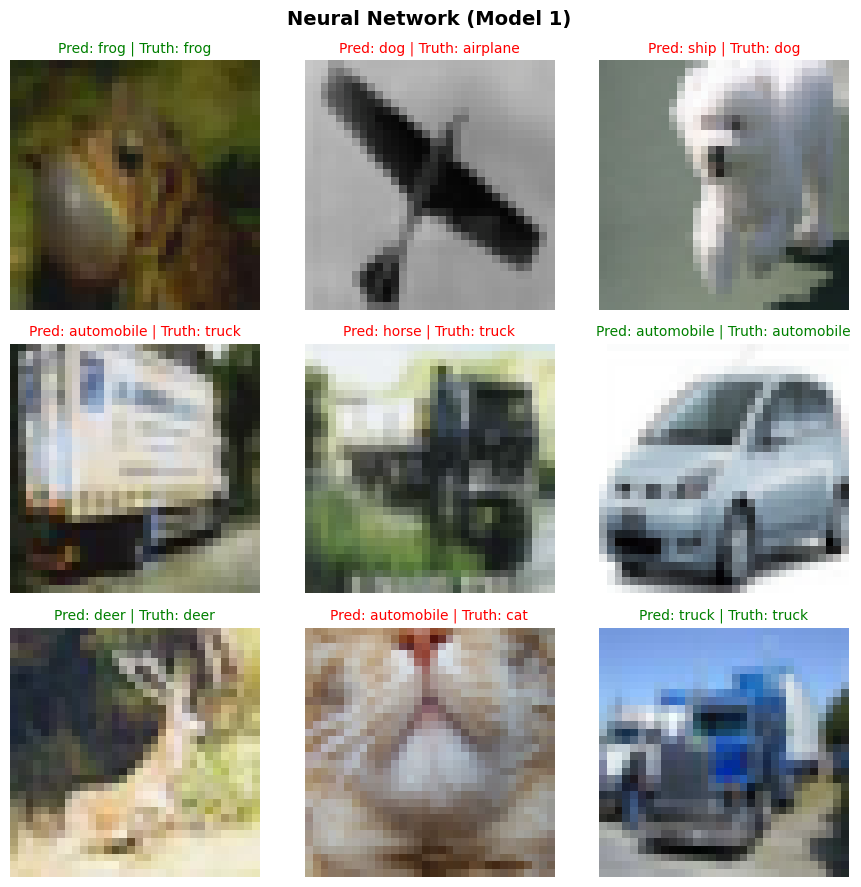

Predicted: [6, 5, 8, 1, 7, 1, 4, 1, 9]
Truth:     [6, 0, 5, 9, 9, 1, 4, 3, 9]


In [147]:
# TinyVGG (Model 2) predictions
pred_classes_1 = plot_predictions(
    model=model_1,
    test_samples=test_samples,
    test_labels=test_labels,
    class_names=class_names,
    title="Neural Network (Model 1)"
)
print("Predicted:", pred_classes_1.tolist())
print("Truth:    ", test_labels)

Making predictions for ModelV1 (Linear) – Confusion Matrix: 100%|██████████| 313/313 [00:01<00:00, 201.51it/s]


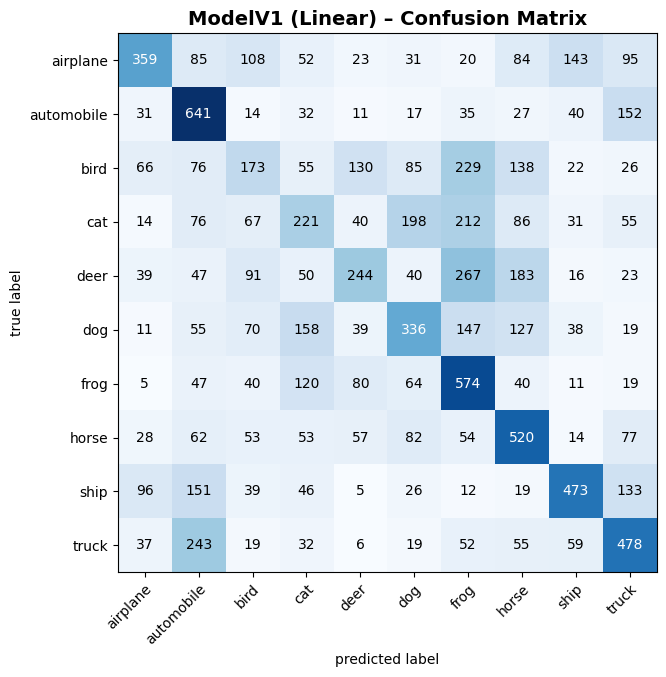

Making predictions for TinyVGG (Model 2) – Confusion Matrix: 100%|██████████| 313/313 [00:02<00:00, 153.38it/s]


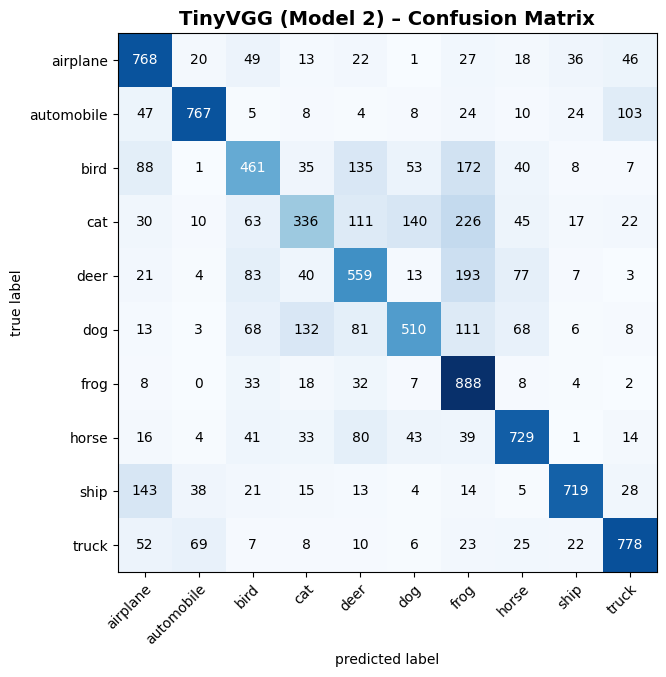

Making predictions for AlexNet (Model 3) – Confusion Matrix: 100%|██████████| 313/313 [00:02<00:00, 119.12it/s]


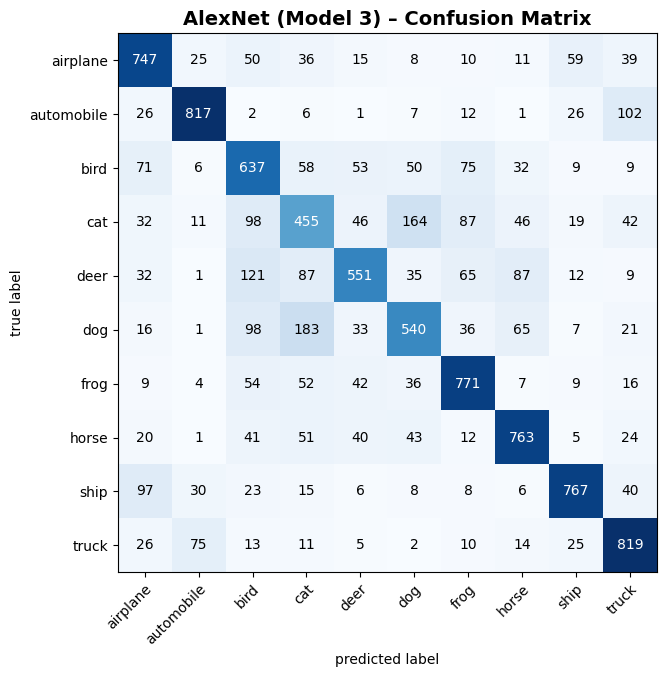

In [148]:
# Confusion matrices for all three models
confmat_1 = plot_confusion_matrix_for_model(
    model=model_1, dataloader=test_dataloader,
    class_names=class_names, title="ModelV1 (Linear) – Confusion Matrix"
)

confmat_2 = plot_confusion_matrix_for_model(
    model=model_2, dataloader=test_dataloader,
    class_names=class_names, title="TinyVGG (Model 2) – Confusion Matrix"
)

confmat_3 = plot_confusion_matrix_for_model(
    model=model_3, dataloader=test_dataloader,
    class_names=class_names, title="AlexNet (Model 3) – Confusion Matrix"
)

# Discussion 
 
 In this lab experiment, we used the models Neural Network, TinyVGG and Alexnet for image classification. Both TinyVGG and AlexNet achieved around 65-68% accuracy compared to just around 40% for the simple NN. This result helped us understand that convolutional layers are better for image classification problems. AlexNet achieved the highest accuracy (68.67%) with 10 epochs, similarly TinyVGG achieved 65.14% for same nummber of epochs, and NN achieved 40.17. Same optimizer, Adam was used for all of these models, with learning rate (lr) of 0.001. The fully connected NN model ignores the spatial structure of images by flattening the input, leading to poor performance. It also has high parameter count without the benefit of weight sharing that CNNs provide. During experimentation, we observed that Adam optimizer is highly sensitive to learning rate. Using lr=0.1 caused the TinyVGG model to diverge (accuracy dropped to  around 10%), while lr=0.001 produced stable convergence. This highlights the importance of proper hyperparameter tuning. Keeping the epochs, the optimizers and their learning rate same of all the models, Alexnet performed the best, hence proving better feature extraction capabilities enabled by its deeper architecture and dropout regularization.


## Conclusion

This experiment demonstrates the progressive improvement in image classification performance as architectural complexity increases from simple fully connected networks to deep CNNs. AlexNet achieved the best test accuracy of 68.67% on CIFAR-10, followed by TinyVGG at 65.14%, while the simple NN baseline achieved only 40.17%.

The results validate that convolutional layers are critical for image classification tasks. Deeper architectures with proper regularization (dropout) generalize better. Optimizer and learning rate selection significantly impact model convergence. Future improvements could include data augmentation, learning rate scheduling, batch normalization, and training for more epochs to further improve accuracy.